In [3]:
%load_ext autoreload
%autoreload 2
from scripts.taxonomy_dataset import (
    taxonomy_df,
    X_train,
    X_test,
    y_train,
    y_test,
    groups_train,
    groups_test,
    transformer_train_df,
    transformer_test_df,
)
from scripts.taxonomy_dataset import (
        cross_dataset_splits,
        reason_model,
        X_train_text_embeddings,
        X_test_text_embeddings
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
ANNOTATED FAILURES
Total: 1,859
dataset
A     179
B    1110
C     570
Name: count, dtype: int64

RULE TAXONOMY
failure_type
unknown                                640
repeated_action                        327
constraint_or_policy_violation         227
irrelevant_action                      111
missing_required_argument               62
unresolved_prior_error                  61
missing_required_action                 48
unavailable_tool                        47
unsupported_claim                       47
workflow_violation                      46
hallucinated_or_unsupported_value       39
incorrect_state_or_location             35
wrong_tool_or_action                    29
schema_or_format_error                  19
incorrect_state_claim                   17
tool_result_misinterpretation           15
invalid_tool_call                       15
unit_conversion_error                   13
authentication

/Users/user/proj/agent-reliability-ml/notebooks/scripts/taxonomy_dataset.py:673: RuntimeWarning: Rule-stage unknown count: notebook checkpoint was 608, runtime reconstruction produced 640. Continuing through embedding/similarity resolution; the final training dataset is asserted exactly.
  _notebook_checkpoint(


Batches:   0%|          | 0/30 [00:00<?, ?it/s]

/Users/user/proj/agent-reliability-ml/notebooks/scripts/taxonomy_dataset.py:885: RuntimeWarning: Prototype category count: notebook checkpoint was 23, runtime reconstruction produced 20. Continuing through embedding/similarity resolution; the final training dataset is asserted exactly.
  _notebook_checkpoint(
/Users/user/proj/agent-reliability-ml/notebooks/scripts/taxonomy_dataset.py:937: RuntimeWarning: Reference-bank size: notebook checkpoint was 771, runtime reconstruction produced 758. Continuing through embedding/similarity resolution; the final training dataset is asserted exactly.
  _notebook_checkpoint(


Batches:   0%|          | 0/12 [00:00<?, ?it/s]

...

/Users/user/proj/agent-reliability-ml/notebooks/scripts/taxonomy_dataset.py:1262: RuntimeWarning: Remaining KMeans cluster sizes: notebook checkpoint was {0: 38, 1: 40, 2: 16, 3: 52, 4: 61, 5: 43, 6: 56, 7: 27}, runtime reconstruction produced {0: 53, 1: 65, 2: 38, 3: 28, 4: 29, 5: 31, 6: 53, 7: 59}. Continuing through embedding/similarity resolution; the final training dataset is asserted exactly.
  _notebook_checkpoint(
/Users/user/proj/agent-reliability-ml/notebooks/scripts/taxonomy_dataset.py:1523: RuntimeWarning: Hybrid confidence distribution: notebook checkpoint was {'high': 196, 'medium': 80, 'low': 57}, runtime reconstruction produced {'high': 212, 'medium': 81, 'low': 63}. Continuing through embedding/similarity resolution; the final training dataset is asserted exactly.
  _notebook_checkpoint(
/Users/user/proj/agent-reliability-ml/notebooks/scripts/taxonomy_dataset.py:1564: RuntimeWarning: Pre-selection ambiguous count: notebook checkpoint was 57, runtime reconstruction prod

\nNOTEBOOK REPRODUCTION CHECK
Runtime five-family samples: 1,776
Notebook reference samples: 1,779
\nRuntime family counts:
failure_family
workflow_error           798
constraint_error         387
tool_use_error           275
grounding_state_error    274
reasoning_value_error     42
Name: count, dtype: int64
\nNotebook reference family counts:
workflow_error           789
constraint_error         397
tool_use_error           274
grounding_state_error    264
reasoning_value_error     55
dtype: int64

TAXONOMY DATASET
Total samples:       1,776
Total trajectories:  419

TRAIN / TEST SPLIT
Train samples:       1,489
Test samples:        287
Train trajectories:  335
Test trajectories:   84

TRAIN LABEL DISTRIBUTION
              count  percentage
family_label                   
0               660       44.33
1               317       21.29
2               237       15.92
3               244       16.39
4                31        2.08

TEST LABEL DISTRIBUTION
              count  percentag

Batches:   0%|          | 0/24 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Train embeddings: (1489, 384)
Train labels:     (1489,)
Test embeddings:  (287, 384)
Test labels:      (287,)


In [7]:
texts = {
    "current_only": (
        taxonomy_df["current_text"]
        .fillna("")
        .astype(str)
        .tolist()
    ),

    "context_only": (
        taxonomy_df["context_text"]
        .fillna("")
        .astype(str)
        .tolist()
    ),

    "context_current": (
        "[CONTEXT]\n"
        + taxonomy_df["context_text"]
        .fillna("")
        .astype(str)
        + "\n\n[CURRENT]\n"
        + taxonomy_df["current_text"]
        .fillna("")
        .astype(str)
    ).tolist(),
}

embeddings = {}

for name, text_list in texts.items():

    print(f"Embedding {name}...")

    embeddings[name] = reason_model.encode(
        text_list,
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True,
    )

Embedding current_only...


Batches:   0%|          | 0/28 [00:00<?, ?it/s]

Embedding context_only...


Batches:   0%|          | 0/28 [00:00<?, ?it/s]

Embedding context_current...


Batches:   0%|          | 0/28 [00:00<?, ?it/s]

In [8]:
train_group_set = set(groups_train)
test_group_set = set(groups_test)

print("Group overlap:", len(train_group_set & test_group_set))

train_mask = taxonomy_df["group_id"].isin(
    train_group_set
)

test_mask = taxonomy_df["group_id"].isin(
    test_group_set
)

embedding_splits = {}

for name, X in embeddings.items():

    embedding_splits[name] = {
        "train": X[train_mask.to_numpy()],
        "test": X[test_mask.to_numpy()],
    }

    print(
        name,
        embedding_splits[name]["train"].shape,
        embedding_splits[name]["test"].shape,
    )

Group overlap: 0
current_only (1489, 384) (287, 384)
context_only (1489, 384) (287, 384)
context_current (1489, 384) (287, 384)


In [9]:
family_names = [
    "workflow_error",
    "constraint_error",
    "tool_use_error",
    "grounding_state_error",
    "reasoning_value_error",
]

In [10]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import pandas as pd
import numpy as np

In [11]:
def make_mlp():
    return MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        batch_size=32,
        learning_rate_init=1e-3,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=20,
        random_state=42,
    )

In [12]:
mlp_results = []
mlp_models = {}

for name, split in embedding_splits.items():

    print("\n" + "=" * 80)
    print(f"MLP — {name}")
    print("=" * 80)

    model = make_mlp()

    model.fit(
        split["train"],
        y_train,
    )

    pred = model.predict(
        split["test"],
    )

    accuracy = accuracy_score(
        y_test,
        pred,
    )

    balanced_acc = balanced_accuracy_score(
        y_test,
        pred,
    )

    macro_f1 = f1_score(
        y_test,
        pred,
        average="macro",
        zero_division=0,
    )

    weighted_f1 = f1_score(
        y_test,
        pred,
        average="weighted",
        zero_division=0,
    )

    mlp_results.append({
        "model": "MLP",
        "input": name,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "iterations": model.n_iter_,
        "final_loss": model.loss_,
    })

    mlp_models[name] = model

    print(
        classification_report(
            y_test,
            pred,
            labels=[0, 1, 2, 3, 4],
            target_names=family_names,
            digits=4,
            zero_division=0,
        )
    )

    print("Confusion matrix:")
    print(
        confusion_matrix(
            y_test,
            pred,
            labels=[0, 1, 2, 3, 4],
        )
    )


MLP — current_only
                       precision    recall  f1-score   support

       workflow_error     0.5530    0.5290    0.5407       138
     constraint_error     0.5574    0.4857    0.5191        70
       tool_use_error     0.3235    0.2895    0.3056        38
grounding_state_error     0.2407    0.4333    0.3095        30
reasoning_value_error     0.8333    0.4545    0.5882        11

             accuracy                         0.4739       287
            macro avg     0.5016    0.4384    0.4526       287
         weighted avg     0.5018    0.4739    0.4820       287

Confusion matrix:
[[73 15 20 30  0]
 [31 34  2  3  0]
 [17  5 11  5  0]
 [ 8  7  1 13  1]
 [ 3  0  0  3  5]]

MLP — context_only
                       precision    recall  f1-score   support

       workflow_error     0.5614    0.2319    0.3282       138
     constraint_error     0.4444    0.8000    0.5714        70
       tool_use_error     0.2432    0.2368    0.2400        38
grounding_state_error     0.

In [13]:
mlp_results_df = (
    pd.DataFrame(mlp_results)
    .sort_values(
        "macro_f1",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(mlp_results_df)

,model,input,accuracy,balanced_accuracy,macro_f1,weighted_f1,iterations,final_loss
0,MLP,context_current,0.494774,0.478737,0.477358,0.497922,32,0.374230
1,MLP,current_only,0.473868,0.438410,0.452628,0.481970,27,0.302754
2,MLP,context_only,0.400697,0.442836,0.408175,0.381357,31,0.570514


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import pandas as pd

lr_results = []
lr_models = {}

for name, split in embedding_splits.items():

    print("\n" + "=" * 80)
    print(f"Logistic Regression — {name}")
    print("=" * 80)

    model = LogisticRegression(
        class_weight=None,
        max_iter=5000,
        random_state=42,
    )

    model.fit(
        split["train"],
        y_train,
    )

    pred = model.predict(
        split["test"],
    )

    result = {
        "model": "LogisticRegression",
        "input": name,
        "accuracy": accuracy_score(y_test, pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "macro_f1": f1_score(
            y_test, pred,
            average="macro",
            zero_division=0,
        ),
        "weighted_f1": f1_score(
            y_test, pred,
            average="weighted",
            zero_division=0,
        ),
    }

    lr_results.append(result)
    lr_models[name] = model

    print(classification_report(
        y_test,
        pred,
        labels=[0, 1, 2, 3, 4],
        target_names=family_names,
        digits=4,
        zero_division=0,
    ))

lr_results_df = pd.DataFrame(lr_results)

display(
    lr_results_df.sort_values(
        "macro_f1",
        ascending=False,
    )
)


Logistic Regression — current_only
                       precision    recall  f1-score   support

       workflow_error     0.6230    0.5507    0.5846       138
     constraint_error     0.5584    0.6143    0.5850        70
       tool_use_error     0.3030    0.2632    0.2817        38
grounding_state_error     0.2708    0.4333    0.3333        30
reasoning_value_error     0.8571    0.5455    0.6667        11

             accuracy                         0.5157       287
            macro avg     0.5225    0.4814    0.4903       287
         weighted avg     0.5370    0.5157    0.5215       287


Logistic Regression — context_only
                       precision    recall  f1-score   support

       workflow_error     0.5827    0.5362    0.5585       138
     constraint_error     0.5208    0.7143    0.6024        70
       tool_use_error     0.4000    0.1053    0.1667        38
grounding_state_error     0.2449    0.4000    0.3038        30
reasoning_value_error     0.8000    0.3636

,model,input,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,LogisticRegression,current_only,0.515679,0.481391,0.490268,0.521487
2,LogisticRegression,context_current,0.494774,0.474923,0.477660,0.498444
1,LogisticRegression,context_only,0.501742,0.423883,0.426273,0.488459


In [15]:
results_df = pd.concat(
    [
        lr_results_df,
        mlp_results_df,
    ],
    ignore_index=True,
)

results_df = results_df.sort_values(
    ["input", "macro_f1"],
    ascending=[True, False],
)

display(results_df)

,model,input,accuracy,balanced_accuracy,macro_f1,weighted_f1,iterations,final_loss
2,LogisticRegression,context_current,0.494774,0.474923,0.477660,0.498444,NaN,NaN
3,MLP,context_current,0.494774,0.478737,0.477358,0.497922,32.0,0.374230
1,LogisticRegression,context_only,0.501742,0.423883,0.426273,0.488459,NaN,NaN
5,MLP,context_only,0.400697,0.442836,0.408175,0.381357,31.0,0.570514
0,LogisticRegression,current_only,0.515679,0.481391,0.490268,0.521487,NaN,NaN
4,MLP,current_only,0.473868,0.438410,0.452628,0.481970,27.0,0.302754


In [16]:
display(
    results_df.pivot(
        index="input",
        columns="model",
        values=[
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "weighted_f1",
        ],
    )
)

accuracy            balanced_accuracy            \
model           LogisticRegression       MLP LogisticRegression       MLP   
input                                                                       
context_current           0.494774  0.494774           0.474923  0.478737   
context_only              0.501742  0.400697           0.423883  0.442836   
current_only              0.515679  0.473868           0.481391  0.438410   

                          macro_f1                  weighted_f1            
model           LogisticRegression       MLP LogisticRegression       MLP  
input                                                                      
context_current           0.477660  0.477358           0.498444  0.497922  
context_only              0.426273  0.408175           0.488459  0.381357  
current_only              0.490268  0.452628           0.521487  0.481970

In [17]:
import pandas as pd
from pathlib import Path


# ============================================================
# 1. Combine LR + MLP results
# ============================================================

results_df = pd.concat(
    [
        lr_results_df.copy(),
        mlp_results_df.copy(),
    ],
    ignore_index=True,
)


# Keep only the metrics we want in the research table
metric_columns = [
    "model",
    "input",
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "weighted_f1",
]

results_df = results_df[
    metric_columns
].copy()


# ============================================================
# 2. Sort by primary metric
# ============================================================

results_df = results_df.sort_values(
    "macro_f1",
    ascending=False,
).reset_index(drop=True)

print("\nFULL RESULTS")
print("=" * 80)

display(results_df)


# ============================================================
# 3. Pivot table for easy LR vs MLP comparison
# ============================================================

comparison_pivot = results_df.pivot(
    index="input",
    columns="model",
    values=[
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
        "weighted_f1",
    ],
)

print("\nMODEL COMPARISON")
print("=" * 80)

display(comparison_pivot)


# ============================================================
# 4. Direct MLP - LR improvement per input representation
# ============================================================

lr_compare = (
    lr_results_df[
        [
            "input",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "weighted_f1",
        ]
    ]
    .copy()
    .set_index("input")
)

mlp_compare = (
    mlp_results_df[
        [
            "input",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "weighted_f1",
        ]
    ]
    .copy()
    .set_index("input")
)


delta_df = (
    mlp_compare
    - lr_compare
)

delta_df = delta_df.rename(
    columns={
        "accuracy": "delta_accuracy",
        "balanced_accuracy": "delta_balanced_accuracy",
        "macro_f1": "delta_macro_f1",
        "weighted_f1": "delta_weighted_f1",
    }
)

delta_df = delta_df.reset_index()

print("\nMLP - LOGISTIC REGRESSION")
print("=" * 80)

display(delta_df)


# ============================================================
# 5. Best model for each input representation
# ============================================================

best_by_input = (
    results_df
    .sort_values(
        "macro_f1",
        ascending=False,
    )
    .groupby(
        "input",
        as_index=False,
    )
    .first()
)

print("\nBEST MODEL BY INPUT")
print("=" * 80)

display(best_by_input)


# ============================================================
# 6. Overall best experiment
# ============================================================

best_result = (
    results_df
    .sort_values(
        "macro_f1",
        ascending=False,
    )
    .iloc[0]
)

print("\nBEST OVERALL EXPERIMENT")
print("=" * 80)

print(
    f"Model: {best_result['model']}"
)

print(
    f"Input: {best_result['input']}"
)

print(
    f"Accuracy: "
    f"{best_result['accuracy']:.4f}"
)

print(
    f"Balanced accuracy: "
    f"{best_result['balanced_accuracy']:.4f}"
)

print(
    f"Macro F1: "
    f"{best_result['macro_f1']:.4f}"
)

print(
    f"Weighted F1: "
    f"{best_result['weighted_f1']:.4f}"
)


# ============================================================
# 7. Save results
# ============================================================

OUTPUT_DIR = Path("results")
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


results_path = (
    OUTPUT_DIR
    / "taxonomy_lr_vs_mlp_results.csv"
)

delta_path = (
    OUTPUT_DIR
    / "taxonomy_lr_vs_mlp_deltas.csv"
)

best_path = (
    OUTPUT_DIR
    / "taxonomy_best_by_input.csv"
)


results_df.to_csv(
    results_path,
    index=False,
)

delta_df.to_csv(
    delta_path,
    index=False,
)

best_by_input.to_csv(
    best_path,
    index=False,
)


print("\nSaved:")
print(results_path)
print(delta_path)
print(best_path)


FULL RESULTS


,model,input,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,LogisticRegression,current_only,0.515679,0.481391,0.490268,0.521487
1,LogisticRegression,context_current,0.494774,0.474923,0.477660,0.498444
2,MLP,context_current,0.494774,0.478737,0.477358,0.497922
3,MLP,current_only,0.473868,0.438410,0.452628,0.481970
4,LogisticRegression,context_only,0.501742,0.423883,0.426273,0.488459
5,MLP,context_only,0.400697,0.442836,0.408175,0.381357



MODEL COMPARISON


accuracy            balanced_accuracy            \
model           LogisticRegression       MLP LogisticRegression       MLP   
input                                                                       
context_current           0.494774  0.494774           0.474923  0.478737   
context_only              0.501742  0.400697           0.423883  0.442836   
current_only              0.515679  0.473868           0.481391  0.438410   

                          macro_f1                  weighted_f1            
model           LogisticRegression       MLP LogisticRegression       MLP  
input                                                                      
context_current           0.477660  0.477358           0.498444  0.497922  
context_only              0.426273  0.408175           0.488459  0.381357  
current_only              0.490268  0.452628           0.521487  0.481970


MLP - LOGISTIC REGRESSION


,input,delta_accuracy,delta_balanced_accuracy,delta_macro_f1,delta_weighted_f1
0,context_current,0.000000,0.003814,-0.000301,-0.000522
1,context_only,-0.101045,0.018953,-0.018098,-0.107101
2,current_only,-0.041812,-0.042981,-0.037640,-0.039517



BEST MODEL BY INPUT


,input,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,context_current,LogisticRegression,0.494774,0.474923,0.477660,0.498444
1,context_only,LogisticRegression,0.501742,0.423883,0.426273,0.488459
2,current_only,LogisticRegression,0.515679,0.481391,0.490268,0.521487



BEST OVERALL EXPERIMENT
Model: LogisticRegression
Input: current_only
Accuracy: 0.5157
Balanced accuracy: 0.4814
Macro F1: 0.4903
Weighted F1: 0.5215

Saved:
results/taxonomy_lr_vs_mlp_results.csv
results/taxonomy_lr_vs_mlp_deltas.csv
results/taxonomy_best_by_input.csv


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Matplotlib is building the font cache; this may take a moment.


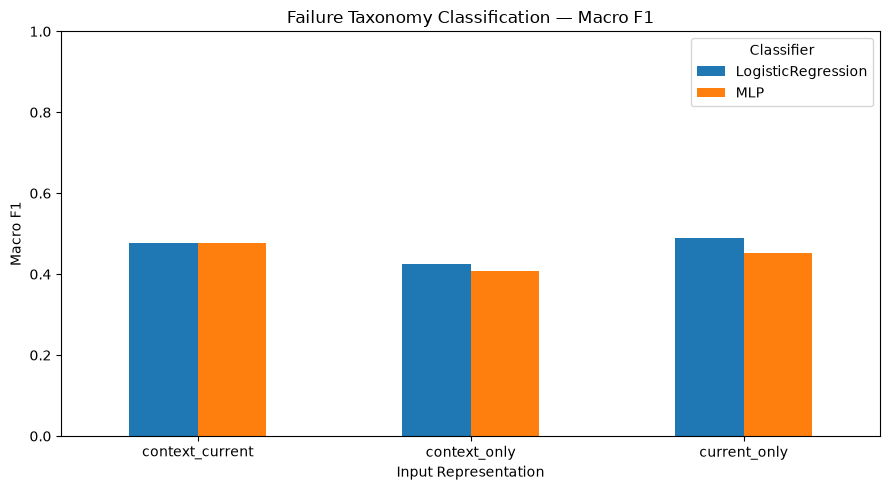

In [18]:
import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# Plot 1: Macro F1 — LR vs MLP
# ============================================================

plot_df = (
    results_df
    .pivot(
        index="input",
        columns="model",
        values="macro_f1",
    )
)

ax = plot_df.plot(
    kind="bar",
    figsize=(9, 5),
)

ax.set_title(
    "Failure Taxonomy Classification — Macro F1"
)
ax.set_xlabel(
    "Input Representation"
)
ax.set_ylabel(
    "Macro F1"
)
ax.set_ylim(
    0,
    1,
)

ax.legend(
    title="Classifier"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.savefig(
    "results/macro_f1_lr_vs_mlp.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

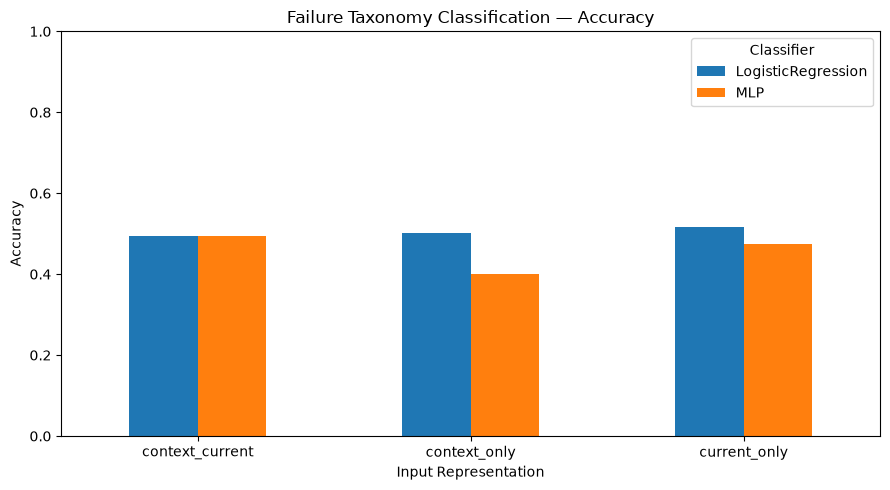

In [19]:
# ============================================================
# Plot 2: Accuracy — LR vs MLP
# ============================================================

plot_df = (
    results_df
    .pivot(
        index="input",
        columns="model",
        values="accuracy",
    )
)

ax = plot_df.plot(
    kind="bar",
    figsize=(9, 5),
)

ax.set_title(
    "Failure Taxonomy Classification — Accuracy"
)
ax.set_xlabel(
    "Input Representation"
)
ax.set_ylabel(
    "Accuracy"
)
ax.set_ylim(
    0,
    1,
)

ax.legend(
    title="Classifier"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.savefig(
    "results/accuracy_lr_vs_mlp.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

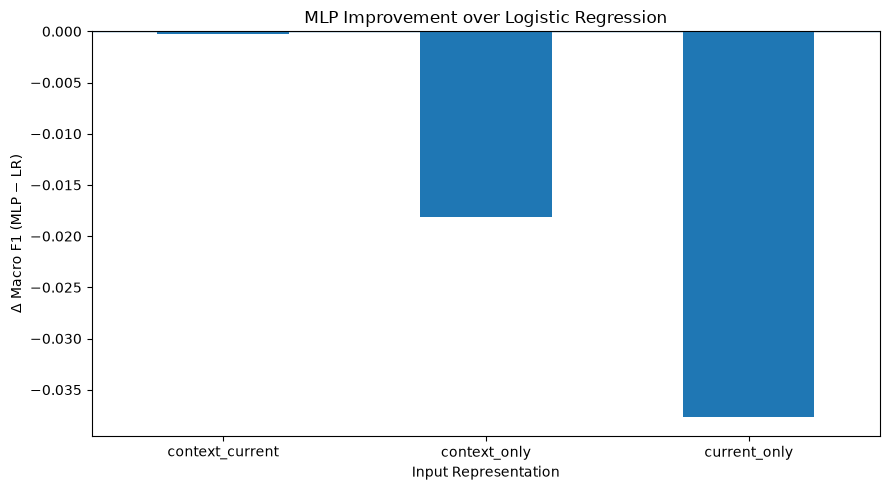

In [20]:
# ============================================================
# Plot 3: MLP improvement over Logistic Regression
# ============================================================

plot_df = (
    delta_df
    .set_index("input")
)

ax = plot_df[
    "delta_macro_f1"
].plot(
    kind="bar",
    figsize=(9, 5),
)

ax.axhline(
    0,
    linewidth=1,
)

ax.set_title(
    "MLP Improvement over Logistic Regression"
)
ax.set_xlabel(
    "Input Representation"
)
ax.set_ylabel(
    "Δ Macro F1 (MLP − LR)"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.savefig(
    "results/macro_f1_delta_mlp_vs_lr.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

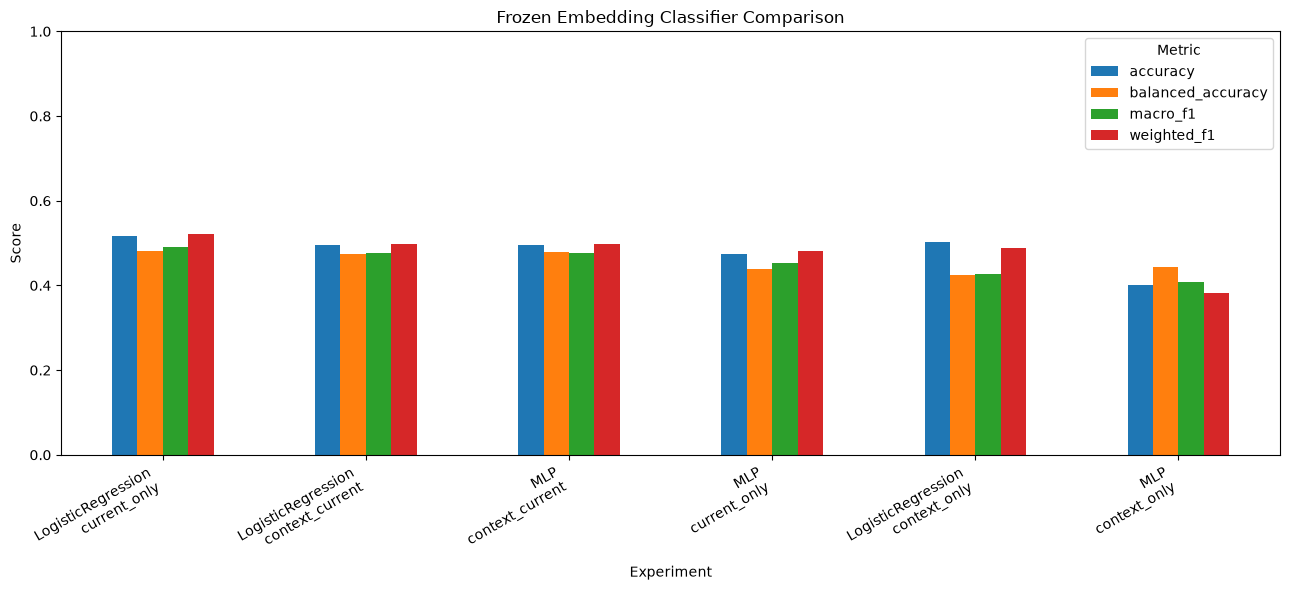

In [21]:
# ============================================================
# Plot 4: Overall metric comparison
# ============================================================

metrics = [
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "weighted_f1",
]

plot_df = results_df.copy()

plot_df["experiment"] = (
    plot_df["model"]
    + "\n"
    + plot_df["input"]
)

plot_df = (
    plot_df
    .set_index("experiment")[metrics]
)

ax = plot_df.plot(
    kind="bar",
    figsize=(13, 6),
)

ax.set_title(
    "Frozen Embedding Classifier Comparison"
)

ax.set_xlabel(
    "Experiment"
)

ax.set_ylabel(
    "Score"
)

ax.set_ylim(
    0,
    1,
)

ax.legend(
    title="Metric"
)

plt.xticks(
    rotation=30,
    ha="right",
)

plt.tight_layout()

plt.savefig(
    "results/frozen_embedding_model_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

This is a very clean result, and it answers the research question from this stage quite clearly:

> **The nonlinear MLP does not improve over Logistic Regression on the frozen embeddings.**

In fact, the best model remains:

```text
LogisticRegression + current_only
Accuracy:        0.5157
Balanced Acc.:   0.4814
Macro F1:        0.4903
Weighted F1:     0.5215
```

The MLP results are consistently weaker or essentially tied:

| Input           | LR Macro F1 | MLP Macro F1 |    Δ MLP−LR |
| --------------- | ----------: | -----------: | ----------: |
| current_only    |  **0.4903** |       0.4526 | **−0.0376** |
| context_only    |  **0.4263** |       0.4082 | **−0.0181** |
| context_current |  **0.4777** |       0.4774 |      ~0.000 |

So the conclusion is **not**:

> “Logistic Regression is too simple.”

The conclusion is closer to:

> **The frozen 384-dimensional embedding already exposes most of the usable information in a form that a linear classifier can exploit. Adding a small nonlinear classifier does not uncover substantial additional structure.**

That is important because it narrows down the bottleneck.

For `context_current`, LR and MLP are basically identical:

```text
LR  Macro F1 = 0.477660
MLP Macro F1 = 0.477358
Δ            = -0.000301
```

This is especially useful evidence. You suspected that LR might fail to model the interaction between context and current step. If that interaction were already encoded in the frozen vector but merely required a nonlinear boundary, the MLP should have improved substantially. It didn't.

So now the stronger hypothesis is:

[
\boxed{\text{The bottleneck is the representation, not classifier nonlinearity.}}
]

Your generic embedding model compresses:

```text
context
+
current action
```

into one fixed 384-dimensional vector **before** the taxonomy classifier learns anything. LR and MLP both receive only that compressed vector. Neither can go back into the token sequence and learn that, for example:

```text
previous tool result = failure
current assistant claim = success
```

constitutes a grounding/workflow contradiction.

A fine-tuned transformer can.

Your experiment sequence now gives a very logical progression:

```text
Majority baseline
       ↓
TF-IDF + linear model
       ↓
Frozen semantic embeddings + LR
       ↓
Frozen semantic embeddings + MLP
       ↓
Finding:
nonlinearity alone does not solve it
       ↓
NEXT:
fine-tuned contextual representation
```

There is also a second strong finding from the input ablation. Across both classifier types, `context_only` is weakest, while simply concatenating context and current does not beat `current_only`:

```text
                     LR       MLP
current_only         .490      .453
context_current      .478      .477
context_only         .426      .408
```

So the data currently supports:

> **The current erroneous action contains the strongest directly accessible signal. Historical context contains useful signal, but generic frozen embeddings do not effectively convert extra context into better failure-family discrimination.**

That's exactly the motivation you needed before fine-tuning BERT. You are no longer moving to a transformer merely because “bigger models might work better.” You have an experimentally supported reason:

> **We need to learn the text representation jointly with the taxonomy task, particularly to learn context–current relationships.**

I would now freeze these CSVs as your **Frozen Representation Study** results:

```text
taxonomy_lr_vs_mlp_results.csv
taxonomy_lr_vs_mlp_deltas.csv
taxonomy_best_by_input.csv
```

and move to the next experiment:

### **Fine-Tuned Transformer Context Ablation**

Use exactly the same three inputs:

```text
Transformer — current_only
Transformer — context_only
Transformer — context_current
```

with exactly the same 335/84 trajectory split and the same five labels.

The central comparison becomes:

[
F1_{\text{Transformer}}(context+current)
\quad \text{vs} \quad
0.4903
]

and, even more importantly:

[
F1_{\text{Transformer}}(context+current)
\quad \text{vs} \quad
F1_{\text{Transformer}}(current)
]

If `context_current` finally overtakes `current_only`, you'll have direct evidence that **task-specific contextual representation learning can exploit trajectory history in a way that frozen embeddings cannot**.
